# Head Pose (Yaw) Regressor Model Evaluation

This notebook compares different CNN architectures for head yaw angle regression:
1. Attention-based CNN with CBAM (Convolutional Block Attention Module)
2. Custom ResNet-based CNN
3. Transfer Learning with pretrained ResNet50
4. Transfer Learning with pretrained MobileNetV2

In [1]:
import keras
keras.config.enable_unsafe_deserialization()

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import os
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Add, Lambda, GlobalAveragePooling2D, GlobalMaxPooling2D, Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation, Add, GlobalAveragePooling2D, Multiply, Reshape, Permute, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2
from tensorflow.keras.applications import ResNet50, MobileNetV2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold

## Load the preprocessed dataset

In [2]:
# Load the preprocessed dataset 
with open('../../datasets/regression/data_20000.npy', 'rb') as data, open('../../datasets/regression/label_20000.npy', 'rb') as label:
    dataset = np.load(data)
    print(dataset.shape)
    labels = np.load(label)
    print(labels.shape)

(20000, 128, 128, 3)
(20000, 3)


## Join both the dataset and labels into a single dataframe
This dataset contains images and their `yaw` values

In [3]:
# Extract yaw values only
yaw_labels = labels[:, 1] 
df = pd.DataFrame({
    'image': list(dataset),
    'label': yaw_labels
})

df.head()

,image,label
0,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",30.915585
1,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",-70.093781
2,"[[[86, 96, 98], [86, 96, 98], [85, 95, 97], [8...",-59.824131
3,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], ...",77.033363
4,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0], [29, 29, 29...",-60.159260


## Split the dataset into training, testing and validation

In [4]:
validation_split = 0.4

num_train_samples = int((1 - validation_split) * len(df))
testing = df[num_train_samples:]
training = df[:num_train_samples]

num_validation_samples = int(len(testing) * 0.5)
testing = testing[num_validation_samples:]
validation = testing[:num_validation_samples]

print(f'Training: {training.shape[0]}')
print(f'Testing: {testing.shape[0]}')
print(f'Validation: {validation.shape[0]}')

Training: 12000
Testing: 4000
Validation: 4000


## Define training, testing and validation data

In [5]:
# x values
x_training = training['image']
x_testing = testing['image']
x_validation = validation['image']

# y values
y_training = training['label']
y_testing = testing['label']
y_validation = validation['label']

x_training = np.array([np.array(xi).astype(np.float32) for xi in x_training])
y_training = np.array([np.array(yi).astype(np.float32) for yi in y_training])
x_validation = np.array([np.array(xi).astype(np.float32) for xi in x_validation])
y_validation = np.array([np.array(yi).astype(np.float32) for yi in y_validation])
x_testing = np.array([np.array(xi).astype(np.float32) for xi in x_testing])
y_testing = np.array([np.array(yi).astype(np.float32) for yi in y_testing])

# Normalize the data to [0, 1] range
x_training = x_training.astype('float32') / 255.0
x_validation = x_validation.astype('float32') / 255.0
x_testing = x_testing.astype('float32') / 255.0

## Define training callbacks and data augmentation

In [6]:
# Function to ensure directory exists
def ensure_dir_exists(directory):
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

# Callbacks for training
def get_callbacks(model_name):
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=8,
        min_delta=0.001,
        mode='min',
        restore_best_weights=True
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,
        patience=4,
        min_lr=0.00001
    )
    
    # Make sure experiments directory exists
    output_dir = '../../trained_models'
    ensure_dir_exists(output_dir)
    
    model_checkpoint = ModelCheckpoint(
        f'{output_dir}/{model_name}.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min'
    )
    
    return [early_stopping, reduce_lr, model_checkpoint]

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(x_training)

## Utility functions for evaluation

In [7]:
# Function to evaluate models
def evaluate_model(model, x_test, y_test, model_name):
    predictions = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    
    print(f"===== {model_name} Evaluation =====")
    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'R-squared: {r2}')
    
    # Plot predicted vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, predictions)
    plt.xlabel('Actual values')
    plt.ylabel('Predicted values')
    plt.title(f'{model_name} - Predicted vs. Actual values')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # Return metrics as dictionary
    return {'model': model_name, 'mae': mae, 'mse': mse, 'rmse': rmse, 'r2': r2}

# Function to plot training history
def plot_training_history(history, model_name):
    metrics = pd.DataFrame(history.history)
    
    # Plot loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['loss'], label='Training Loss')
    plt.plot(metrics['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} - Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Plot MAE
    plt.subplot(1, 2, 2)
    plt.plot(metrics['mae'], label='Training MAE')
    plt.plot(metrics['val_mae'], label='Validation MAE')
    plt.title(f'{model_name} - Training vs Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save the training history plot
    history_dir = '../../model/experiments'
    ensure_dir_exists(history_dir)
    plt.savefig(f'{history_dir}/{model_name}_training_history.png')
    
    plt.show()
    
    # Save training history as JSON for future reference
    history_data = {k: [float(val) for val in v] for k, v in history.history.items()}
    import json
    with open(f'{history_dir}/{model_name}_training_history.json', 'w') as f:
        json.dump(history_data, f)
    
    return metrics

## 1. Attention-based CNN with CBAM

This implementation uses a Convolutional Block Attention Module (CBAM) that helps the model focus on the most relevant parts of the face image. The module consists of:

1. **Channel Attention**: Focuses on "what" is important by weighting each channel
2. **Spatial Attention**: Focuses on "where" is important by weighting each spatial location

The key improvement here is to use named functions instead of Lambda layers for better compatibility.

In [8]:
# Define named functions for the operations instead of lambda functions
def mean_channel(x, axis=-1, keepdims=True):
    return K.mean(x, axis=axis, keepdims=keepdims)

def max_channel(x, axis=-1, keepdims=True):
    return K.max(x, axis=axis, keepdims=keepdims)

# Register the custom functions
tf.keras.utils.get_custom_objects().update({'mean_channel': mean_channel})
tf.keras.utils.get_custom_objects().update({'max_channel': max_channel})

In [9]:
def channel_attention(x, ratio=8):
    channel_axis = -1 
    filters = x.shape[channel_axis]
    if filters is None or filters < ratio : 
        mlp_filters_reduced = max(1, int(filters / 2)) if filters else 1 
    else:
        mlp_filters_reduced = filters // ratio
    
    # Shared MLP - defining layers once for potential true sharing if desired later,
    # or use distinct names if not strictly sharing weights yet.
    # For this example, we'll keep them as distinct instances within each path for simplicity of the current fix.
    mlp_reduced_avg = Conv2D(mlp_filters_reduced, kernel_size=1, use_bias=True, activation='relu', name=f'{x.name.split(":")[0]}_channel_mlp_reduced_avg')
    mlp_expanded_avg = Conv2D(filters, kernel_size=1, use_bias=True, name=f'{x.name.split(":")[0]}_channel_mlp_expanded_avg')

    mlp_reduced_max = Conv2D(mlp_filters_reduced, kernel_size=1, use_bias=True, activation='relu', name=f'{x.name.split(":")[0]}_channel_mlp_reduced_max')
    mlp_expanded_max = Conv2D(filters, kernel_size=1, use_bias=True, name=f'{x.name.split(":")[0]}_channel_mlp_expanded_max')
    
    # Average Pooling Path
    avg_pool = GlobalAveragePooling2D(name=f'{x.name.split(":")[0]}_channel_avg_pool')(x)
    avg_pool = Reshape((1, 1, filters), name=f'{x.name.split(":")[0]}_channel_reshape_avg')(avg_pool)
    avg_pool = mlp_reduced_avg(avg_pool)
    avg_pool = mlp_expanded_avg(avg_pool)

    # Max Pooling Path
    max_pool = GlobalMaxPooling2D(name=f'{x.name.split(":")[0]}_channel_max_pool')(x)
    max_pool = Reshape((1, 1, filters), name=f'{x.name.split(":")[0]}_channel_reshape_max')(max_pool)
    max_pool = mlp_reduced_max(max_pool)
    max_pool = mlp_expanded_max(max_pool)

    summed_features = Add(name=f'{x.name.split(":")[0]}_channel_add')([avg_pool, max_pool])
    channel_weights = Activation('sigmoid', name=f'{x.name.split(":")[0]}_channel_sigmoid')(summed_features)
    
    return Multiply(name=f'{x.name.split(":")[0]}_channel_multiply')([x, channel_weights])

def spatial_attention(x, kernel_size=7):
    channel_axis = -1  # 'channels_last'

    # Using named functions instead of Lambda layers
    avg_pool = Lambda(
        mean_channel,
        output_shape=lambda s: (s[0], s[1], s[2], 1),
        arguments={'axis': channel_axis, 'keepdims': True},
        name=f'{x.name.split(":")[0]}_spatial_avg_pool_lambda'
    )(x)

    max_pool = Lambda(
        max_channel,
        output_shape=lambda s: (s[0], s[1], s[2], 1),
        arguments={'axis': channel_axis, 'keepdims': True},
        name=f'{x.name.split(":")[0]}_spatial_max_pool_lambda'
    )(x)

    concat = Concatenate(axis=channel_axis, 
                         name=f'{x.name.split(":")[0]}_spatial_concat')([avg_pool, max_pool])

    attention_feature_map = Conv2D(
        1, kernel_size=kernel_size, strides=1, padding='same',
        activation='sigmoid', use_bias=False,
        name=f'{x.name.split(":")[0]}_spatial_conv_sigmoid'
    )(concat)

    return Multiply(name=f'{x.name.split(":")[0]}_spatial_multiply')([x, attention_feature_map])

def cbam_block(x, ratio=8, kernel_size=7):
    x_channel = channel_attention(x, ratio)
    x_spatial = spatial_attention(x_channel, kernel_size)
    return x_spatial

In [10]:
def create_attention_cnn_model(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)
    
    # First convolutional block
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Second convolutional block
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Third convolutional block
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Fourth convolutional block
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    
    # Apply attention block
    x = cbam_block(x)
    
    # Fully connected layers
    x = Flatten()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output for yaw angle
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [11]:
# Create attention-based CNN model
attention_model = create_attention_cnn_model()
attention_model.summary()

2025-06-07 15:21:39.886978: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2025-06-07 15:21:39.887053: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-06-07 15:21:39.887079: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-06-07 15:21:39.887343: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-06-07 15:21:39.887390: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 32)        │          0 │ max_pooling2d[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 32)        │          0 │ max_pooling2d[0]… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │          0 │ keras_tensor_5_c… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │          0 │ keras_tensor_5_c… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 4)   │        132 │ keras_tensor_5_c… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 4)   │        132 │ keras_tensor_5_c… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │        160 │ keras_tensor_5_c… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │        160 │ keras_tensor_5_c… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │          0 │ keras_tensor_5_c… │
│ (Add)               │                   │            │ keras_tensor_5_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 1, 1, 32)  │          0 │ keras_tensor_5_c… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ keras_tensor_5_cha… │ (None, 64, 64,    │          0 │ max_pooling2d[0]

 Total params: 9,676,001 (36.91 MB)

 Trainable params: 9,674,081 (36.90 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [12]:
# Train attention-based CNN model
attention_history = attention_model.fit(
    x_training,
    y_training,
    epochs=25,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('attention_cnn_yaw_regressor')
)

Epoch 1/25


2025-06-07 15:23:13.680699: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


375/375 ━━━━━━━━━━━━━━━━━━━━ 98s 237ms/step - loss: 689.7928 - mae: 18.7842 - val_loss: 663.0005 - val_mae: 21.7484 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 224ms/step - loss: 135.3927 - mae: 8.9887 - val_loss: 70.6734 - val_mae: 6.1844 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 225ms/step - loss: 102.1918 - mae: 7.7284 - val_loss: 62.0464 - val_mae: 5.7933 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - loss: 88.0437 - mae: 7.1152 - val_loss: 59.9913 - val_mae: 6.0333 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - loss: 78.7190 - mae: 6.8048 - val_loss: 28.9502 - val_mae: 4.0215 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - loss: 70.6094 - mae: 6.3752 - val_loss: 48.9226 - val_mae: 5.1890 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 223ms/step - loss: 72.2387 - mae: 6.3686 - val_loss: 23.7881 - val_mae: 3.5976 

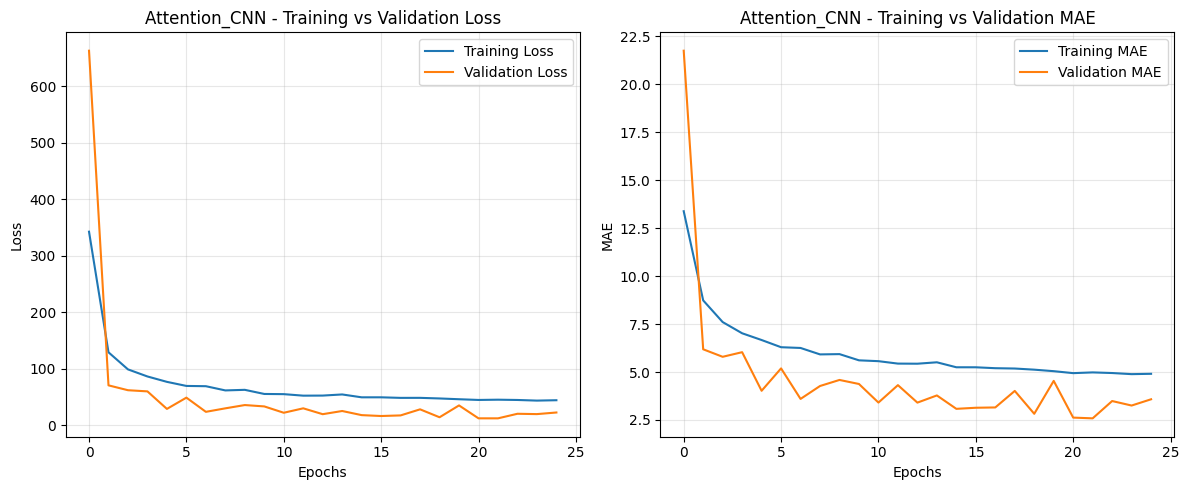

125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step
===== Attention_CNN Evaluation =====
MAE: 2.5850532054901123
MSE: 12.270391464233398
RMSE: 3.502911855047654
R-squared: 0.995864987373352


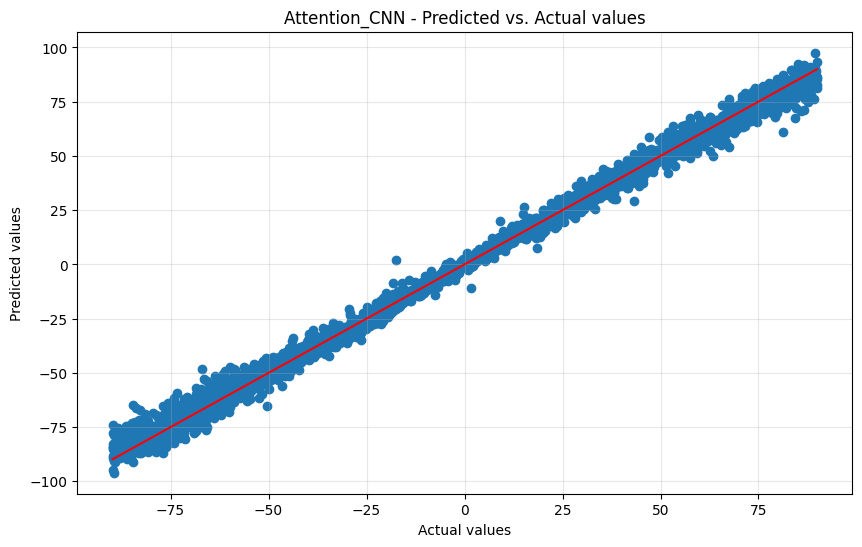

In [13]:
# Plot training history and evaluate attention-based CNN model
attention_metrics = plot_training_history(attention_history, 'Attention_CNN')
attention_results = evaluate_model(attention_model, x_testing, y_testing, 'Attention_CNN')

## 2. Custom ResNet-based CNN

This model uses a custom architecture with residual connections inspired by ResNet.

In [14]:
def residual_block(x, filters, kernel_size=3, strides=1, activation='relu'):
    # Shortcut connection (identity or projection)
    shortcut = x
    
    # First convolution
    y = Conv2D(filters, kernel_size=kernel_size, strides=strides, padding='same')(x)
    y = BatchNormalization()(y)
    y = Activation(activation)(y)
    
    # Second convolution
    y = Conv2D(filters, kernel_size=kernel_size, strides=1, padding='same')(y)
    y = BatchNormalization()(y)
    
    # If dimensions changed, adjust shortcut with 1x1 conv
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1, strides=strides, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)
    
    # Add shortcut to output
    y = Add()([shortcut, y])
    y = Activation(activation)(y)
    
    return y

In [15]:
def create_custom_resnet_model(input_shape=(128, 128, 3)):
    inputs = Input(shape=input_shape)
    
    # Initial convolution
    x = Conv2D(32, kernel_size=7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=3, strides=2, padding='same')(x)
    
    # Residual blocks
    x = residual_block(x, filters=32)
    x = residual_block(x, filters=32)
    
    # Increase filters and downsample
    x = residual_block(x, filters=64, strides=2)
    x = residual_block(x, filters=64)
    
    # Increase filters and downsample
    x = residual_block(x, filters=128, strides=2)
    x = residual_block(x, filters=128)
    
    # Increase filters and downsample
    x = residual_block(x, filters=256, strides=2)
    x = residual_block(x, filters=256)
    
    # Global pooling
    x = GlobalAveragePooling2D()(x)
    
    # Fully connected layers
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output for yaw angle
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [16]:
# Create and train custom ResNet model
custom_resnet_model = create_custom_resnet_model()
custom_resnet_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │      4,736 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ max_pooling2d_4[… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 32, 32,    │      9,248 │ activation_3[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_12[0][0] 

 Total params: 3,003,457 (11.46 MB)

 Trainable params: 2,998,657 (11.44 MB)

 Non-trainable params: 4,800 (18.75 KB)

In [17]:
# Train custom ResNet model
custom_resnet_history = custom_resnet_model.fit(
    x_training,
    y_training,
    epochs=25,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('custom_resnet_yaw_regressor')
)

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 98s 219ms/step - loss: 943.8820 - mae: 22.8124 - val_loss: 625.7246 - val_mae: 20.1895 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 193ms/step - loss: 208.4964 - mae: 10.7408 - val_loss: 290.8302 - val_mae: 12.3517 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 70s 186ms/step - loss: 159.2943 - mae: 9.4383 - val_loss: 71.0342 - val_mae: 5.9552 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 73s 194ms/step - loss: 96.7161 - mae: 7.4336 - val_loss: 42.9124 - val_mae: 4.5573 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 190ms/step - loss: 82.0193 - mae: 6.8398 - val_loss: 52.5337 - val_mae: 4.8865 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 70s 185ms/step - loss: 119.0864 - mae: 7.6501 - val_loss: 70.3172 - val_mae: 5.5226 - learning_rate: 0.0010
Epoch 7/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 71s 189ms/step - loss: 114.4217 - mae: 7.8711 - val_loss: 42.1601 - 

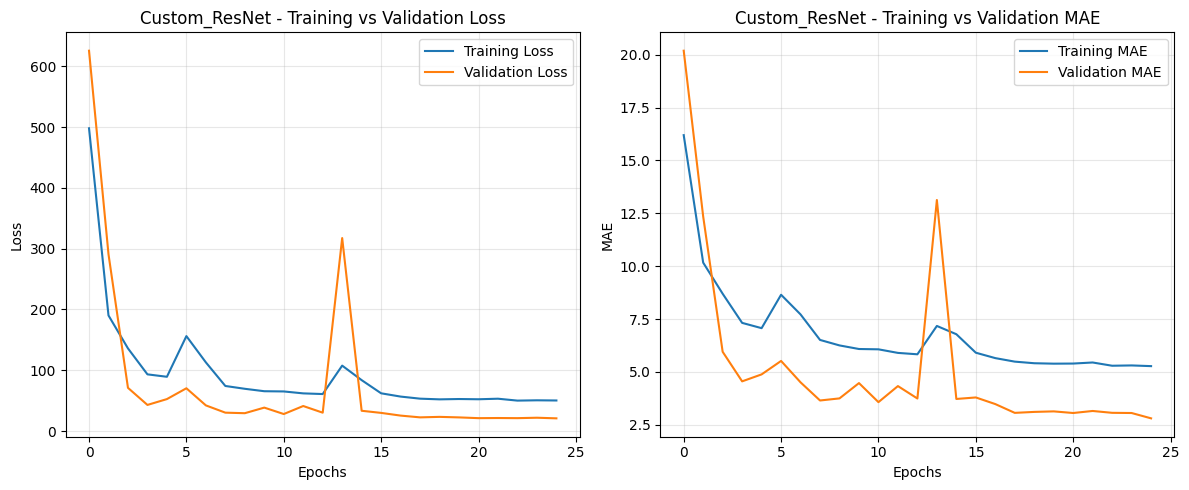

125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
===== Custom_ResNet Evaluation =====
MAE: 2.8086299896240234
MSE: 20.851778030395508
RMSE: 4.566374714190187
R-squared: 0.9929732084274292


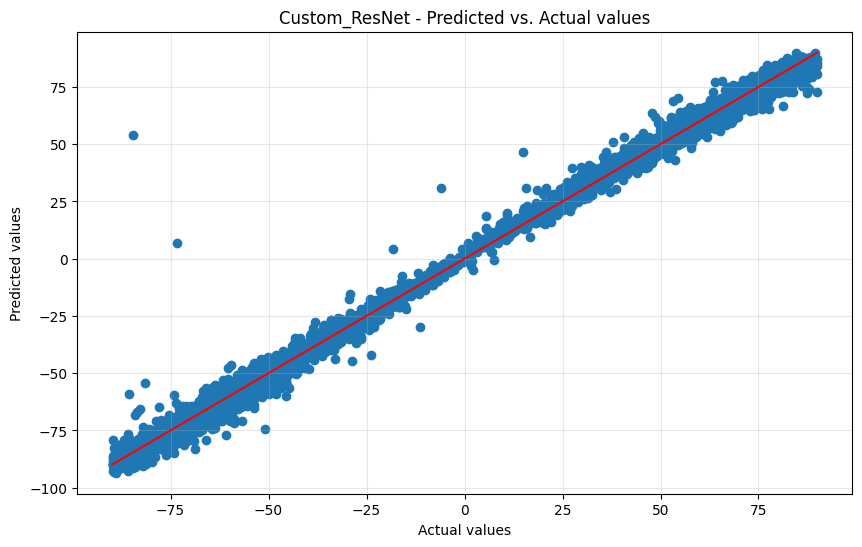

In [18]:
# Plot training history and evaluate custom ResNet model
custom_resnet_metrics = plot_training_history(custom_resnet_history, 'Custom_ResNet')
custom_resnet_results = evaluate_model(custom_resnet_model, x_testing, y_testing, 'Custom_ResNet')

## 3. Transfer Learning with ResNet50

This model utilizes a pre-trained ResNet50 model initially trained on ImageNet and fine-tuned for head yaw regression.

In [19]:
def create_resnet50_model(input_shape=(128, 128, 3)):
    # Load pre-trained ResNet50 without top layers
    base_model = ResNet50(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Create model with custom regression head
    inputs = Input(shape=input_shape)
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output for yaw angle
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model with a lower learning rate for transfer learning
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [20]:
# Create ResNet50 transfer learning model
resnet50_model = create_resnet50_model()
resnet50_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,702,593 (94.23 MB)

 Trainable params: 1,114,881 (4.25 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
# Train ResNet50 model
resnet50_history = resnet50_model.fit(
    x_training,
    y_training,
    epochs=20,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('resnet50_yaw_regressor')
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 49s 105ms/step - loss: 3035.2695 - mae: 49.6388 - val_loss: 2955.3560 - val_mae: 48.8343 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - loss: 2974.4155 - mae: 49.0206 - val_loss: 2917.2454 - val_mae: 48.4950 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 88ms/step - loss: 2978.3145 - mae: 49.0618 - val_loss: 2804.0630 - val_mae: 47.4433 - learning_rate: 1.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 33s 87ms/step - loss: 2828.1169 - mae: 47.6481 - val_loss: 2565.1780 - val_mae: 45.0153 - learning_rate: 1.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 2530.9116 - mae: 44.5296 - val_loss: 2236.7224 - val_mae: 41.3176 - learning_rate: 1.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 85ms/step - loss: 2194.1399 - mae: 40.5039 - val_loss: 1920.8177 - val_mae: 37.3431 - learning_rate: 1.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 86ms/step - loss: 1

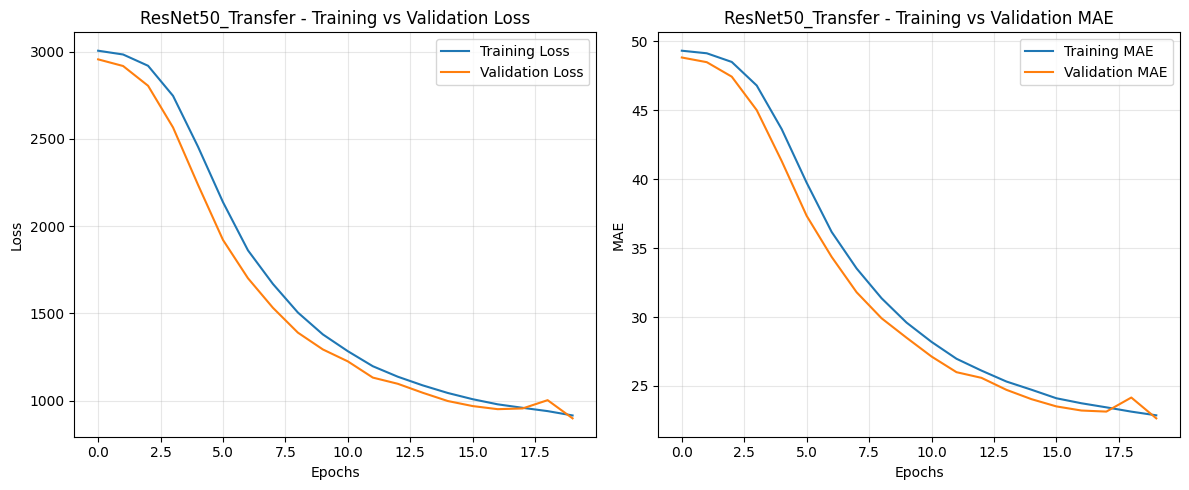

125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step
===== ResNet50_Transfer Evaluation =====
MAE: 22.64883804321289
MSE: 898.5838623046875
RMSE: 29.976388413294345
R-squared: 0.6971873044967651


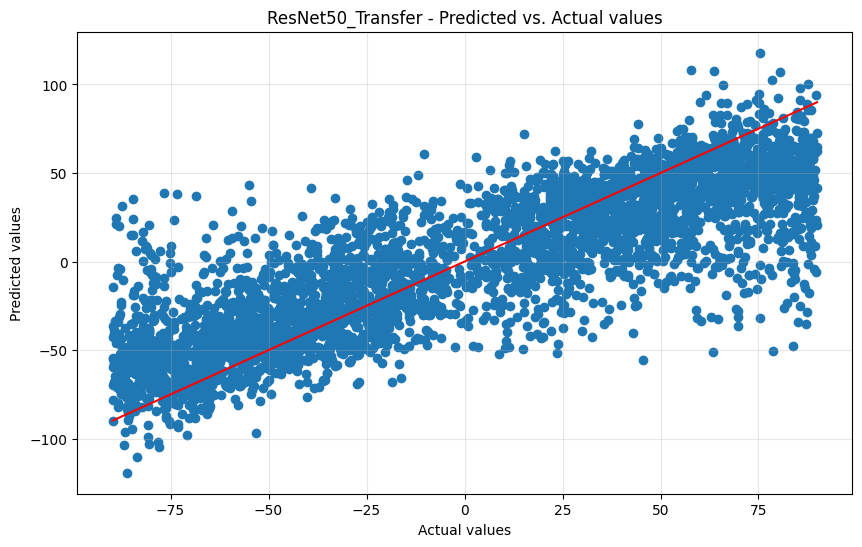

In [22]:
# Plot training history and evaluate ResNet50 model
resnet50_metrics = plot_training_history(resnet50_history, 'ResNet50_Transfer')
resnet50_results = evaluate_model(resnet50_model, x_testing, y_testing, 'ResNet50_Transfer')

## 4. Transfer Learning with MobileNetV2

This model utilizes a pre-trained MobileNetV2 model initially trained on ImageNet and fine-tuned for head yaw regression. MobileNetV2 is a lightweight architecture designed for mobile and edge devices.

In [23]:
def create_mobilenetv2_model(input_shape=(128, 128, 3)):
    # Load pre-trained MobileNetV2 without top layers
    base_model = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
    # Freeze base model layers
    for layer in base_model.layers:
        layer.trainable = False
    
    # Create model with custom regression head
    inputs = Input(shape=input_shape)
    x = base_model(inputs)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1)(x)  # Regression output for yaw angle
    
    model = Model(inputs=inputs, outputs=outputs)
    
    # Compile the model with a lower learning rate for transfer learning
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='mse',
        metrics=['mae']
    )
    
    return model

In [24]:
# Create MobileNetV2 transfer learning model
mobilenetv2_model = create_mobilenetv2_model()
mobilenetv2_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979,649 (11.37 MB)

 Trainable params: 721,665 (2.75 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
# Train MobileNetV2 model
mobilenetv2_history = mobilenetv2_model.fit(
    x_training,
    y_training,
    epochs=20,
    batch_size=32,
    validation_data=(x_validation, y_validation),
    callbacks=get_callbacks('mobilenetv2_yaw_regressor')
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 32s 70ms/step - loss: 3020.6262 - mae: 49.4931 - val_loss: 2813.9622 - val_mae: 47.3792 - learning_rate: 1.0000e-04
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2780.3491 - mae: 46.8741 - val_loss: 2616.9583 - val_mae: 44.8822 - learning_rate: 1.0000e-04
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2599.6465 - mae: 44.5030 - val_loss: 2438.0796 - val_mae: 42.4866 - learning_rate: 1.0000e-04
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2384.5894 - mae: 41.8362 - val_loss: 2308.2466 - val_mae: 40.6625 - learning_rate: 1.0000e-04
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2188.6396 - mae: 39.4071 - val_loss: 2201.7529 - val_mae: 38.8998 - learning_rate: 1.0000e-04
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - loss: 2010.0505 - mae: 37.0164 - val_loss: 2047.3827 - val_mae: 36.6838 - learning_rate: 1.0000e-04
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 20s 52ms/step - loss: 19

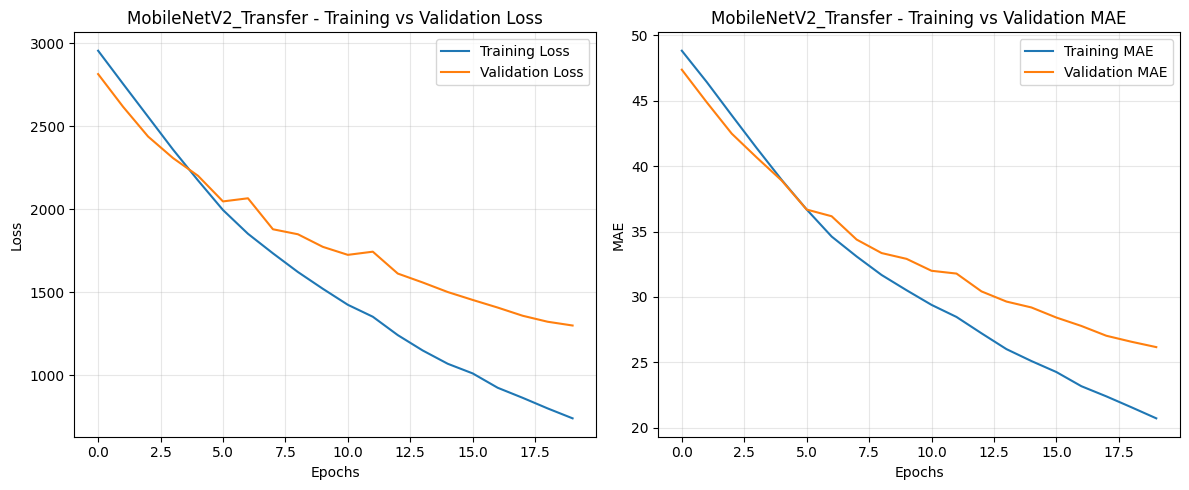

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step
===== MobileNetV2_Transfer Evaluation =====
MAE: 26.162017822265625
MSE: 1300.3101806640625
RMSE: 36.059813929970055
R-squared: 0.5618100166320801


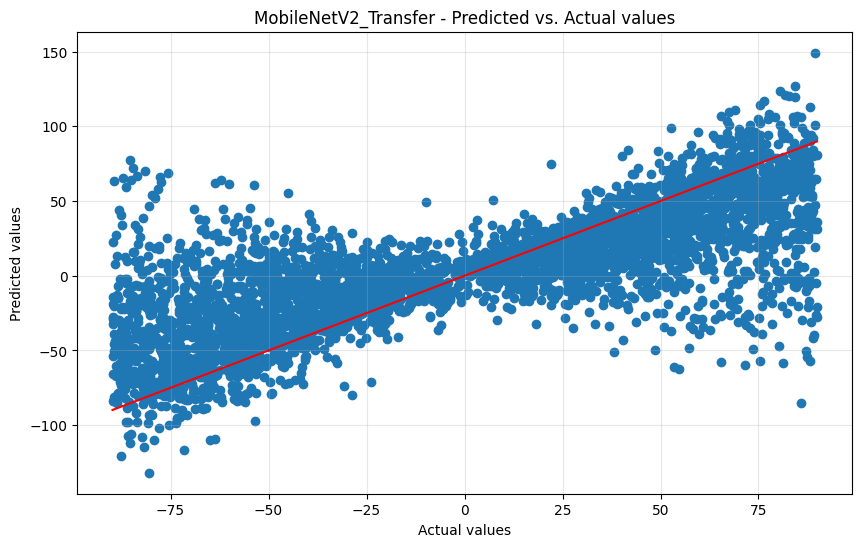

In [26]:
# Plot training history and evaluate MobileNetV2 model
mobilenetv2_metrics = plot_training_history(mobilenetv2_history, 'MobileNetV2_Transfer')
mobilenetv2_results = evaluate_model(mobilenetv2_model, x_testing, y_testing, 'MobileNetV2_Transfer')

## Compare Model Performance

In [27]:
# Create a DataFrame to compare metrics
all_results = pd.DataFrame([
    attention_results, 
    custom_resnet_results, 
    resnet50_results, 
    mobilenetv2_results
])

print("===== Model Performance Comparison =====")
all_results.set_index('model')

===== Model Performance Comparison =====


,mae,mse,rmse,r2
model,,,,
Attention_CNN,2.585053,12.270391,3.502912,0.995865
Custom_ResNet,2.808630,20.851778,4.566375,0.992973
ResNet50_Transfer,22.648838,898.583862,29.976388,0.697187
MobileNetV2_Transfer,26.162018,1300.310181,36.059814,0.561810


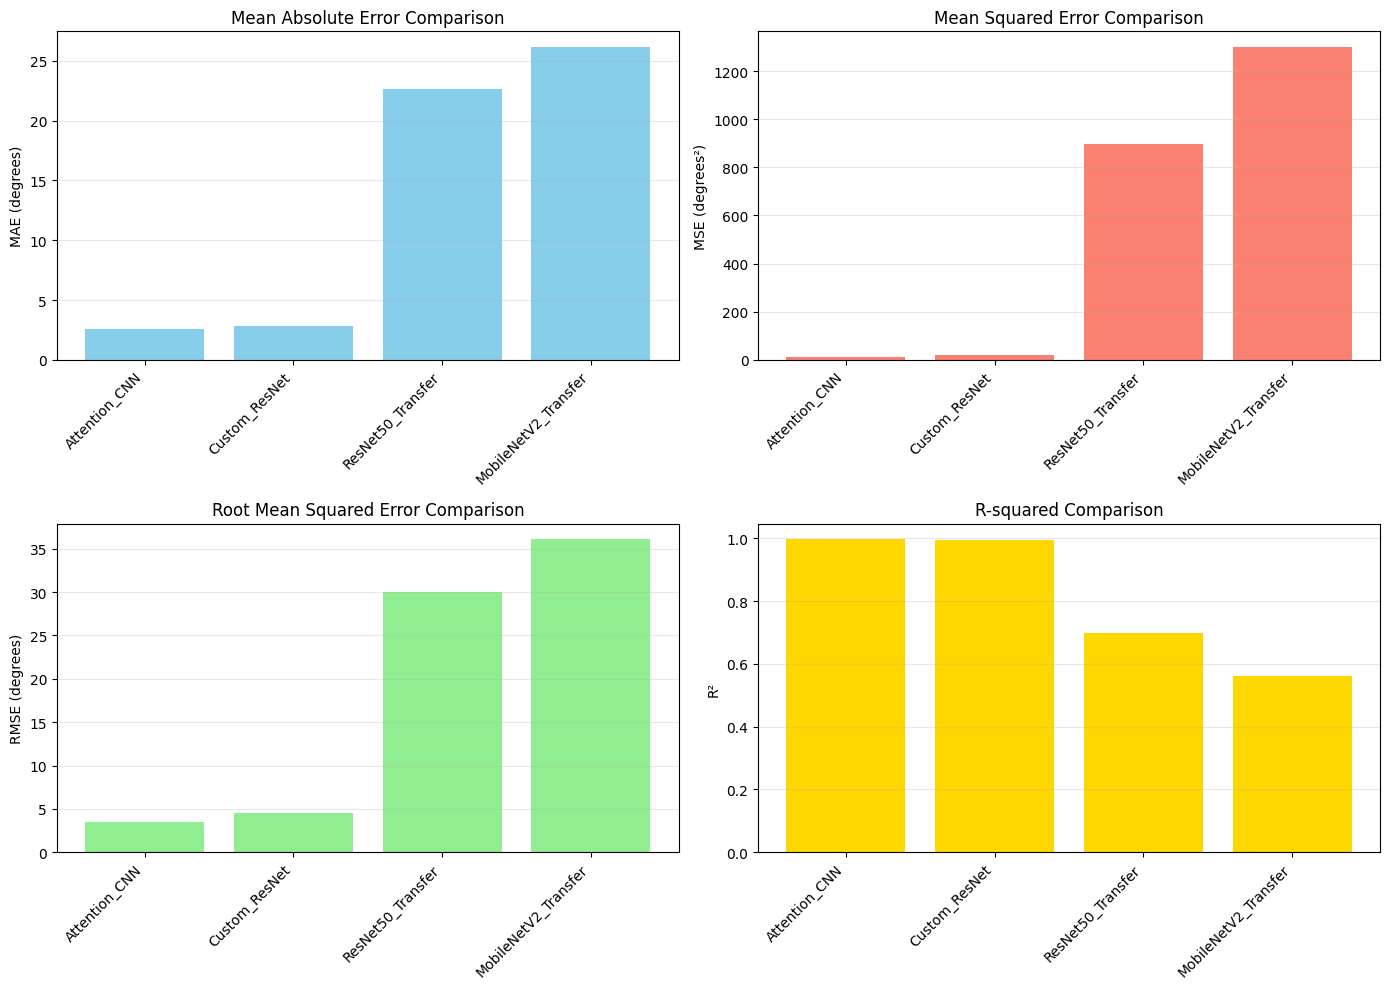

In [28]:
# Visualize comparison with bar plots
plt.figure(figsize=(14, 10))

# MAE comparison
plt.subplot(2, 2, 1)
plt.bar(all_results['model'], all_results['mae'], color='skyblue')
plt.title('Mean Absolute Error Comparison')
plt.ylabel('MAE (degrees)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# MSE comparison
plt.subplot(2, 2, 2)
plt.bar(all_results['model'], all_results['mse'], color='salmon')
plt.title('Mean Squared Error Comparison')
plt.ylabel('MSE (degrees²)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# RMSE comparison
plt.subplot(2, 2, 3)
plt.bar(all_results['model'], all_results['rmse'], color='lightgreen')
plt.title('Root Mean Squared Error Comparison')
plt.ylabel('RMSE (degrees)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# R² comparison
plt.subplot(2, 2, 4)
plt.bar(all_results['model'], all_results['r2'], color='gold')
plt.title('R-squared Comparison')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../model/experiments/model_comparison.png')
plt.show()

## Conclusion

In this notebook, we evaluated four different CNN architectures for head yaw angle regression:

1. **Attention-based CNN with CBAM** - This model uses attention mechanisms to focus on the most relevant parts of the face for yaw angle prediction.
2. **Custom ResNet-based CNN** - A custom architecture with residual connections that help with gradient flow in deep networks.
3. **ResNet50 (Transfer Learning)** - Uses a pre-trained ResNet50 model and fine-tunes it for our specific regression task.
4. **MobileNetV2 (Transfer Learning)** - Uses a pre-trained MobileNetV2 model, offering a more lightweight architecture suitable for deployment on edge devices.

Based on the evaluation metrics, we can determine which model performs best for the head yaw regression task. The comparison considers accuracy (MAE, MSE, RMSE) and model efficiency/complexity.